# Filtro de 1er orden pasa baja

$$H(z)=\frac{1-\alpha}{1-\alpha Z^{-1}}$$

$$y[n] = (1-\alpha)x[n] + \alpha y[n-1]$$

| Tipo de frecuencia         | Expresión                       | Unidad        | Rango matemático completo                           | Rango útil (sin ambigüedad / Nyquist) | Periodicidad |
| -------------------------- | ------------------------------- | ------------- | --------------------------------------------------- | ------------------------------------- | ------------ |
| **Frecuencia analógica**   | ( f )                           | Hz            | ($ 0 \le f < f_s $)                                   | ($ 0 \le f \le \frac{f_s}{2} $)         | No periódica |
| **Frecuencia digital**     | ($\omega = \frac{2\pi f}{f_s} $) | rad/sample    | ($ -\pi \le \omega < \pi $) ó ($ 0 \le \omega < 2\pi $) | ($ 0 \le \omega \le \pi $)              | ($ 2\pi $)     |
| **Frecuencia normalizada** | ($ F = \frac{f}{f_s} $)           | ciclos/sample | ($ 0 \le F < 1 $)                                     | ($ 0 \le F \le 0.5 $)                   | 1            |


In [ ]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [ ]:
fc = 100
fs = 1000

alfa = np.exp(-2*np.pi*fc/fs)

b = [1-alfa]
a = [1, -alfa]

w, h = signal.freqz(b, a) # w is the digital normalized frequency (radians/sample) and h is the frequency response

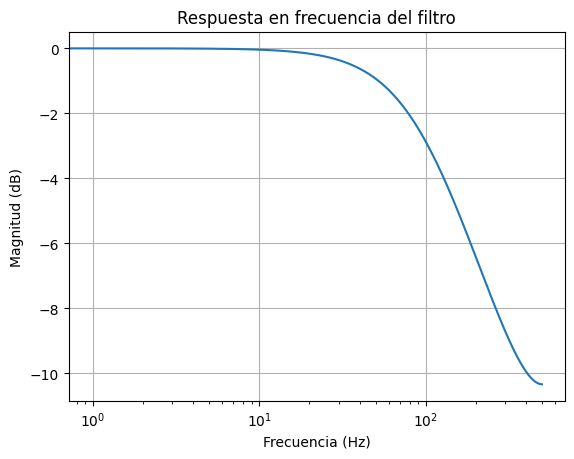

In [ ]:
# Convert w to Hz,  Digital frequency (ω) - radians per sample:
# ω = 2π·f/fs => f = w*fs/(2π)
f_hz = w*fs/(2*np.pi)
magnitude_db = 20*np.log10(np.abs(h))

plt.semilogx(f_hz, magnitude_db)
plt.title('Respuesta en frecuencia del filtro')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.grid()
plt.show()

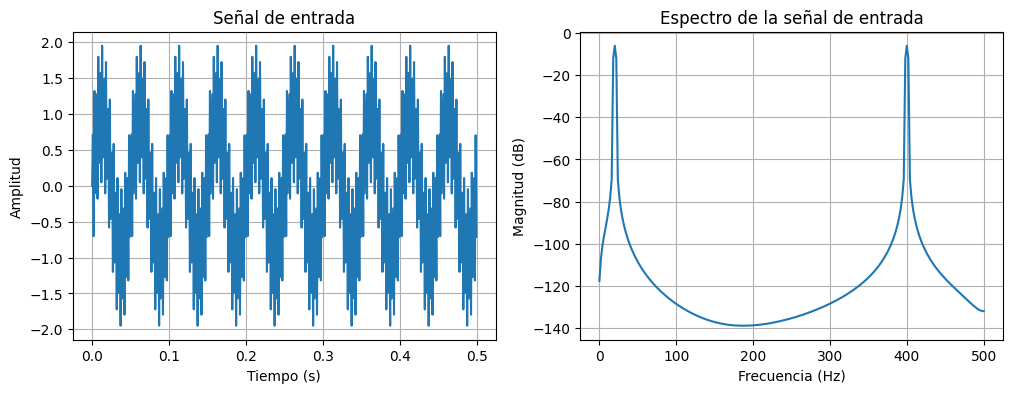

In [ ]:
f1=20
f2=400

w1=2*np.pi*f1/fs
w2=2*np.pi*f2/fs

n = np.arange(0, 500)
t = n/fs

x1 = np.sin(w1*n)
x2 = np.sin(w2*n)

x = x1 + x2

plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(t, x)
plt.title('Señal de entrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()

plt.subplot(1,2,2)
plt.magnitude_spectrum(x, Fs=fs, scale='dB')
plt.title('Espectro de la señal de entrada')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.grid()
plt.show()

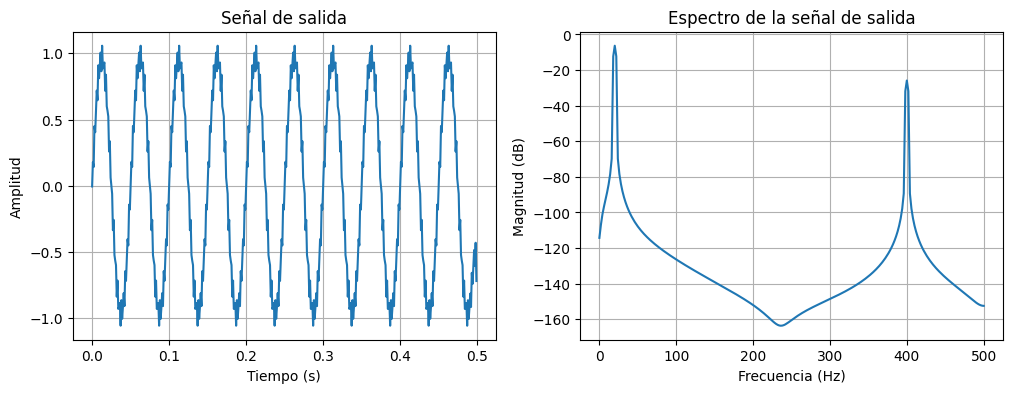

In [ ]:
y = signal.filtfilt(b, a, x)

plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(t, y)
plt.title('Señal de salida')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()

plt.subplot(1,2,2)
plt.magnitude_spectrum(y, Fs=fs, scale='dB')
plt.title('Espectro de la señal de salida')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.grid()
plt.show()

# Filtro pasa baja de 2do orden

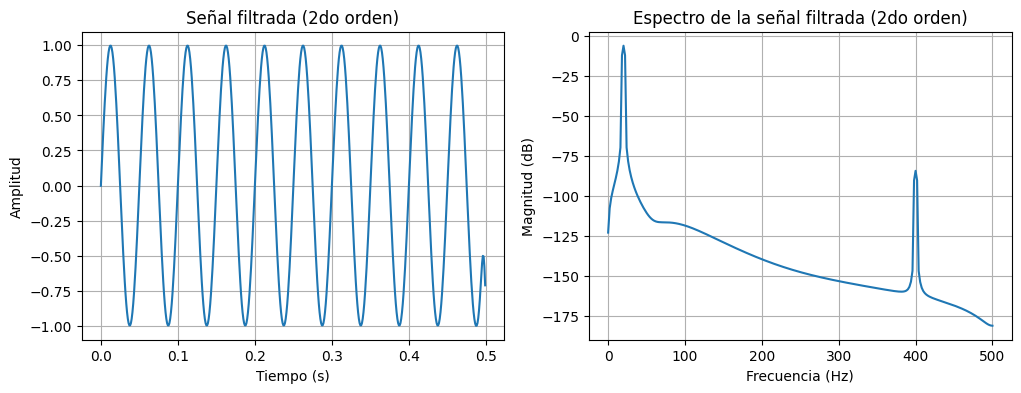

In [ ]:
# Diseñar filtro pasa baja de 2do orden (Butterworth)
fc = 100
fs = 1000

order = 2
b_2nd, a_2nd = signal.butter(order, fc, fs=fs) #signal.butter(order, 2*fc/fs)

# Aplicar el filtro a la señal
y_2nd = signal.filtfilt(b_2nd, a_2nd, x)

# Visualizar resultados
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(t, y_2nd)
plt.title('Señal filtrada (2do orden)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()

plt.subplot(1,2,2)
plt.magnitude_spectrum(y_2nd, Fs=fs, scale='dB')
plt.title('Espectro de la señal filtrada (2do orden)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.grid()
plt.show()